In [2]:
# 라이브러리 호출

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [3]:
# CPU 혹은 GPU 장치 확인

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
# fashion_mnist 데이터셋 내려받기
train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True,
                            transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True,
                            train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.98MB/s]


In [5]:
# fashion_mnist 데이터를 데이터로더에 전달

train_loader=torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader=torch.utils.data.DataLoader(test_dataset, batch_size=100)

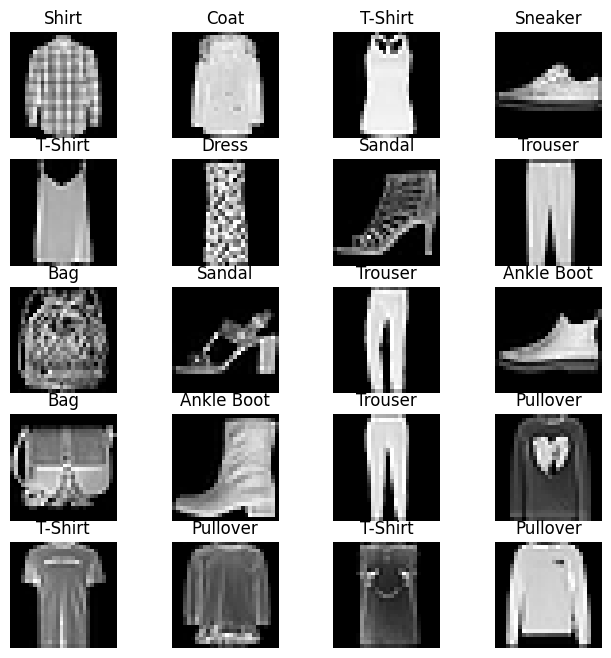

In [6]:
# 분류에 사용될 클래스 정의

labels_map = {0 : 'T-Shirt', 1: 'Trouser', 2 : 'Pullover', 3: 'Dress', 4 : 'Coat'
              , 5: 'Sandal', 6 : 'Shirt', 7 : 'Sneaker', 8 : 'Bag', 9 : 'Ankle Boot'}
fig = plt.figure (figsize=(8,8));
columns = 4;
rows = 5;
for i in range(1, columns*rows +1):
  img_xy = np.random.randint(len(train_dataset));
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

In [13]:
# 심층신경망 모델 생성

class FashionDNN(nn. Module):
  def __init__(self):
      super(FashionDNN, self).__init__()
      self.fc1 = nn.Linear(in_features=784, out_features=256)
      self.drop = nn.Dropout(0.25)
      self.fc2 = nn.Linear(in_features=256, out_features=128)
      self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):
      out = input_data.view(-1, 784)
      out = F.relu(self.fc1(out))
      out = self.drop(out)
      out = F.relu(self.fc2(out))
      out = self.fc3(out)
      return out


In [15]:
# DNN의 파라미터(학습률, 손실함수, 옵티마이저) 정의

learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [16]:
num_epochs = 5
count = 0

loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0

            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1) [1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
          print("Iteration:{}, Loss: {}, Accuracy:{}%".format(count, loss.data, accuracy))

Iteration:500, Loss: 0.5568277835845947, Accuracy:82.9800033569336%
Iteration:1000, Loss: 0.45735809206962585, Accuracy:84.52999877929688%
Iteration:1500, Loss: 0.3724053204059601, Accuracy:84.98999786376953%
Iteration:2000, Loss: 0.38250404596328735, Accuracy:85.26000213623047%
Iteration:2500, Loss: 0.2738770842552185, Accuracy:86.12999725341797%
Iteration:3000, Loss: 0.3157077729701996, Accuracy:86.91999816894531%


In [21]:
# CNN 모델 생성

class FashionCNN(nn. Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential (
          nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
          nn.BatchNorm2d(32),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2, stride=2)
          )
        self.layer2 = nn. Sequential(
          nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
          nn.BatchNorm2d(64),
          nn.ReLU(),
          nn. MaxPool2d(2)
          )
        self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out


In [22]:
# CNN 파라미터 정의

learning_rate = 0.001;
model = FashionCNN();

model.to(device)
criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [24]:
# CNN 학습 [16cell과 동일]

num_epochs = 5
count = 0

loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0

            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1) [1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if not (count % 500):
          print("Iteration:{}, Loss: {}, Accuracy:{}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration:500, Loss: 0.46578913927078247, Accuracy:87.51000213623047%
Iteration:1000, Loss: 0.394118994474411, Accuracy:87.31999969482422%
Iteration:1500, Loss: 0.3170414865016937, Accuracy:86.91000366210938%
Iteration:2000, Loss: 0.20875966548919678, Accuracy:89.11000061035156%
Iteration:2500, Loss: 0.11106712371110916, Accuracy:90.16000366210938%
Iteration:3000, Loss: 0.1977706402540207, Accuracy:89.75%


그외 주석 혹은 교재에 쓰인 코드들 정리

In [ ]:
# GPU 호출

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = Net()
model.to(device)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net()
if torch.cuda.device_count() > 1:
model = nn. DataParallel(net)
model.to(device)


In [ ]:
# np 개념 설명

np.random.randint(10) # 0~10 임의의 숫자 출력
np.random.ranint(1, 10) # 1~9 임의의 숫자 출력
np.random.rand(8) # 0~1 사이의 정규표준분포 난수를 행렬로 (1x8) 출력

np.random.rand(4, 2) # 0~1 사이의 정규표준분포 난수를 행렬로 (4x2) 출력
np.random.randn (8) # 평균이 0이고, 표준편차가 1인 가우시안 정규분포 난수를 행렬로 (1×8) 출력
np.random.randn (4, 2) # 평균이 0이고, 표준편차가 1인 가우시안 정규분포 난수를 행렬로 (4×2) 출력

In [ ]:
# 배열 생성 개념 설명

examp = np.arrange(0, 100, 3) # 1~9 숫자에서 3씩 건너뛴 행렬 생성
examp.resize(6, 4) # 행렬의 크기를 6x4로 조정
examp

examp[3] # 3행에 해당하는 요소를 출력
examp[3,3] # 3행의 3번째 열에 대한 값)을 출력
examp[3][3] # 위와 동일

examp=np.arrange(0, 500, 3)
examp.resize(3, 5, 5)
examp
examp[2][0][3]

In [ ]:
# 클래스와 함수

#함수
def add(num1, num2):
  result = num1 + num2
  return result
print(add(1, 2))
print(add(2, 3))


#클래스
class Calc:
  def __init__(self): ------ 객체를 생성할 때 호출하면 실행되는 초기화 함수
    self.result = 0
  def add(self, num1, num2):
   self.result = num1 + num2
    return self.result

obj1 = Calc()
obj2 = Calc()

print(obj1.add(1, 2))
print(obj1.add(2, 3))
print('------------------')
print(obj2.add(2,2))
print(obj2.add(2,3))

In [ ]:
# 활성화함수 호출 비교

# nn.xx() 사용
inputs = torch.randn(64, 3, 244, 244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
outputs = conv(inputs)
layer = nn.Conv2d(1, 1, 3)

# F.xx() 사용 (혹은 nn.functional)
inputs = torch.rand(64, 3, 244, 244)
weight = torch.rand(64, 3, 3, 3)
bias = torch.randn(64)
outputs=F.conv2d(inputs, weight, bias, padding=1)

In [ ]:
# 정확도
classification accuracy = correct predictions / total predictions 100

# 오류율
error rate = (1 - (correct predictions / total predictions)) 100